<a href="https://colab.research.google.com/github/michellewinata/Phyton-Code-Origin/blob/main/(Updated)_RM_jurnal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("project-droid/DroidCollection")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00003.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/train-00001-of-00003.parquet:   0%|          | 0.00/165M [00:00<?, ?B/s]

data/train-00002-of-00003.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet:   0%|          | 0.00/64.9M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/846598 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/105824 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/105826 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 846598
    })
    dev: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 105824
    })
    test: Dataset({
        features: ['Code', 'Generator', 'Generation_Mode', 'Source', 'Language', 'Sampling_Params', 'Rewriting_Params', 'Label', 'Model_Family'],
        num_rows: 105826
    })
})


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Gabung train + dev + test split dari dataset
df_all = pd.concat([
    pd.DataFrame(dataset['train']),
    pd.DataFrame(dataset['dev']),
    pd.DataFrame(dataset['test'])
])

# Filter Python + 3 label target
df_python = df_all[
    (df_all['Language'] == 'Python') &
    (df_all['Label'].isin(['HUMAN_GENERATED', 'MACHINE_GENERATED', 'MACHINE_REFINED']))
].copy()

# Sampling 5000 per class
df_sampled = df_python.groupby('Label').apply(
    lambda x: x.sample(n=5000, random_state=42)
).reset_index(drop=True)

# Train/test split 80:20
df_train, df_test = train_test_split(
    df_sampled, test_size=0.2, random_state=42, stratify=df_sampled['Label']
)

print(f"Total : {len(df_sampled):,}")
print(f"Train : {len(df_train):,}")
print(f"Test  : {len(df_test):,}")
print("\nTrain distribution:")
print(df_train['Label'].value_counts())
print("\nTest distribution:")
print(df_test['Label'].value_counts())

Total : 15,000
Train : 12,000
Test  : 3,000

Train distribution:
Label
MACHINE_GENERATED    4000
MACHINE_REFINED      4000
HUMAN_GENERATED      4000
Name: count, dtype: int64

Test distribution:
Label
MACHINE_GENERATED    1000
HUMAN_GENERATED      1000
MACHINE_REFINED      1000
Name: count, dtype: int64


/tmp/ipykernel_2888/367006102.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df_python.groupby('Label').apply(


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train = df_train.copy()
df_test  = df_test.copy()

df_train['label_enc'] = le.fit_transform(df_train['Label'])
df_test['label_enc']  = le.transform(df_test['Label'])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'HUMAN_GENERATED': np.int64(0), 'MACHINE_GENERATED': np.int64(1), 'MACHINE_REFINED': np.int64(2)}


In [ ]:
import re
import time
import numpy as np

# 5. STYLOMETRIC FEATURES
def extract_stylometric(code):
    lines = code.split('\n')
    non_empty = [l for l in lines if l.strip()]

    indents      = [len(l) - len(l.lstrip()) for l in non_empty]
    line_lengths = [len(l) for l in non_empty]
    comment_lines = [l for l in lines if l.strip().startswith('#')]
    identifiers  = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)
    func_names   = re.findall(r'def\s+([a-zA-Z_][a-zA-Z0-9_]*)', code)
    control_keywords = ['if ', 'elif ', 'else:', 'for ', 'while ', 'try:', 'except', 'with ']
    control_count = sum(code.count(kw) for kw in control_keywords)

    return {
        'blank_ratio'       : len([l for l in lines if not l.strip()]) / len(lines) if lines else 0,
        'indent_consistency': np.std(indents) if indents else 0,
        'avg_line_length'   : np.mean(line_lengths) if line_lengths else 0,
        'avg_var_length'    : np.mean([len(i) for i in identifiers]) if identifiers else 0,
        'total_lines'       : len(lines),
        'unique_ratio'      : len(set(identifiers)) / len(identifiers) if identifiers else 0,
        'control_count'     : control_count,
        'num_functions'     : len(func_names),
        'comment_density'   : len(comment_lines) / len(lines) if lines else 0,
        'num_imports'       : len(re.findall(r'^\s*(import|from)\s+', code, re.MULTILINE)),
    }

t0 = time.time()
print("Extracting stylometric features...")

stylo_train = pd.DataFrame(df_train['Code'].apply(extract_stylometric).tolist())
stylo_test  = pd.DataFrame(df_test['Code'].apply(extract_stylometric).tolist())

print(f"Done! ({time.time()-t0:.1f}s) | Shape: {stylo_train.shape}")

X_train_s = stylo_train.values
X_test_s  = stylo_test.values

y_train = df_train['label_enc'].values
y_test  = df_test['label_enc'].values

Extracting stylometric features...
Done! (9.6s) | Shape: (12000, 10)


In [ ]:
import matplotlib.pyplot as plt


Stylometric models done! (7.2s)


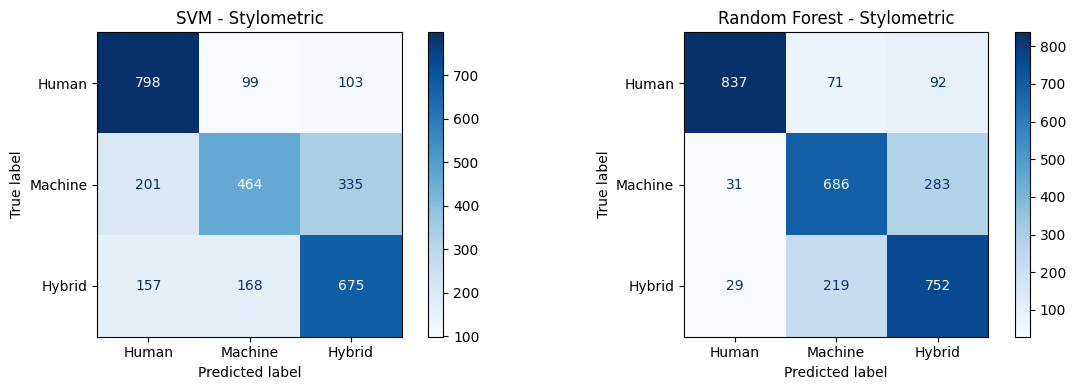

Accuracy  : 0.6457
Precision : 0.6438
Recall    : 0.6457
F1-score  : 0.6384
              precision    recall  f1-score   support

       Human       0.69      0.80      0.74      1000
     Machine       0.63      0.46      0.54      1000
      Hybrid       0.61      0.68      0.64      1000

    accuracy                           0.65      3000
   macro avg       0.64      0.65      0.64      3000
weighted avg       0.64      0.65      0.64      3000

Accuracy  : 0.7583
Precision : 0.7677
Recall    : 0.7583
F1-score  : 0.7613
              precision    recall  f1-score   support

       Human       0.93      0.84      0.88      1000
     Machine       0.70      0.69      0.69      1000
      Hybrid       0.67      0.75      0.71      1000

    accuracy                           0.76      3000
   macro avg       0.77      0.76      0.76      3000
weighted avg       0.77      0.76      0.76      3000



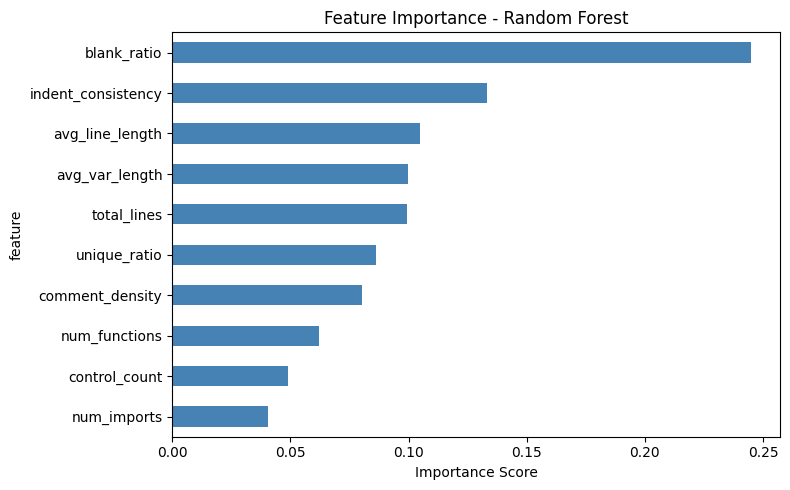

In [ ]:
#  6. MODEL STYLOMETRIC
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)

target_names = ['Human', 'Machine', 'Hybrid']

t0 = time.time()
svm = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm.fit(X_train_s, y_train)
y_pred_svm = svm.predict(X_test_s)

rf = RandomForestClassifier(n_estimators=200,
                             class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_s, y_train)
y_pred_rf = rf.predict(X_test_s)
print(f"Stylometric models done! ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm, ax=ax[0], cmap='Blues',
                                        display_labels=target_names, values_format='d')
ax[0].set_title("SVM - Stylometric")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=ax[1], cmap='Blues',
                                        display_labels=target_names, values_format='d')
ax[1].set_title("Random Forest - Stylometric")
plt.tight_layout()
plt.show()

for name, y_pred in [("SVM", y_pred_svm), ("Random Forest", y_pred_rf)]:
    print("Accuracy  : {:.4f}".format(accuracy_score(y_test, y_pred)))
    print("Precision : {:.4f}".format(precision_score(y_test, y_pred, average='weighted', zero_division=0)))
    print("Recall    : {:.4f}".format(recall_score(y_test, y_pred, average='weighted', zero_division=0)))
    print("F1-score  : {:.4f}".format(f1_score(y_test, y_pred, average='weighted', zero_division=0)))
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# Feature importance
feat_df = pd.DataFrame({'feature': stylo_train.columns, 'importance': rf.feature_importances_})
feat_df.sort_values('importance', ascending=True).plot(
    kind='barh', x='feature', y='importance', figsize=(8, 5),
    legend=False, color='steelblue')
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [ ]:
# 7. CODEBERT
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

print("\nGPU available:", torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using:", device)

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
codebert  = AutoModel.from_pretrained("microsoft/codebert-base")
codebert.eval()
codebert  = codebert.to(device)

# Langsung pakai df_train & df_test hasil sampling
df_train_cb = df_train.reset_index(drop=True)
df_test_cb  = df_test.reset_index(drop=True)

print(f"Train: {df_train_cb.shape} | Test: {df_test_cb.shape}")

def batch_embed(codes, batch_size=32, max_length=128):
    embeddings = []
    total = len(codes)
    for i in range(0, total, batch_size):
        batch  = [str(c)[:800] for c in codes[i:i+batch_size]]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                           max_length=max_length, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = codebert(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls)
        print(f"  {min(i+batch_size, total)}/{total}", end='\r')
    print()
    return np.vstack(embeddings)

t0 = time.time()
print("Extracting train embeddings...")
X_train_cb = batch_embed(df_train_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print("Extracting test embeddings...")
X_test_cb  = batch_embed(df_test_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print(f"CodeBERT done! ({time.time()-t0:.1f}s)")

y_train_cb = df_train_cb['label_enc'].values
y_test_cb  = df_test_cb['label_enc'].values

# 8. FUSION: CodeBERT + Stylometric + TF-IDF
stylo_train_cb        = pd.DataFrame(df_train_cb['Code'].apply(extract_stylometric).tolist())
stylo_test_cb         = pd.DataFrame(df_test_cb['Code'].apply(extract_stylometric).tolist())

scaler_cb             = StandardScaler()
stylo_train_cb_scaled = scaler_cb.fit_transform(stylo_train_cb.values)
stylo_test_cb_scaled  = scaler_cb.transform(stylo_test_cb.values)

tfidf = TfidfVectorizer(max_features=3000, sublinear_tf=True, ngram_range=(1, 2), analyzer='word')
X_train_tfidf = tfidf.fit_transform(df_train_cb['Code'].tolist()).toarray()
X_test_tfidf  = tfidf.transform(df_test_cb['Code'].tolist()).toarray()

X_train_fused = np.hstack([X_train_cb, stylo_train_cb_scaled, X_train_tfidf])
X_test_fused  = np.hstack([X_test_cb,  stylo_test_cb_scaled,  X_test_tfidf])
print("Fused shape:", X_train_fused.shape)


GPU available: False
Using: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train: (12000, 10) | Test: (3000, 10)
Extracting train embeddings...
  12000/12000
Extracting test embeddings...
  3000/3000
CodeBERT done! (7169.6s)
Fused shape: (12000, 3778)


Models done! (176.5s)


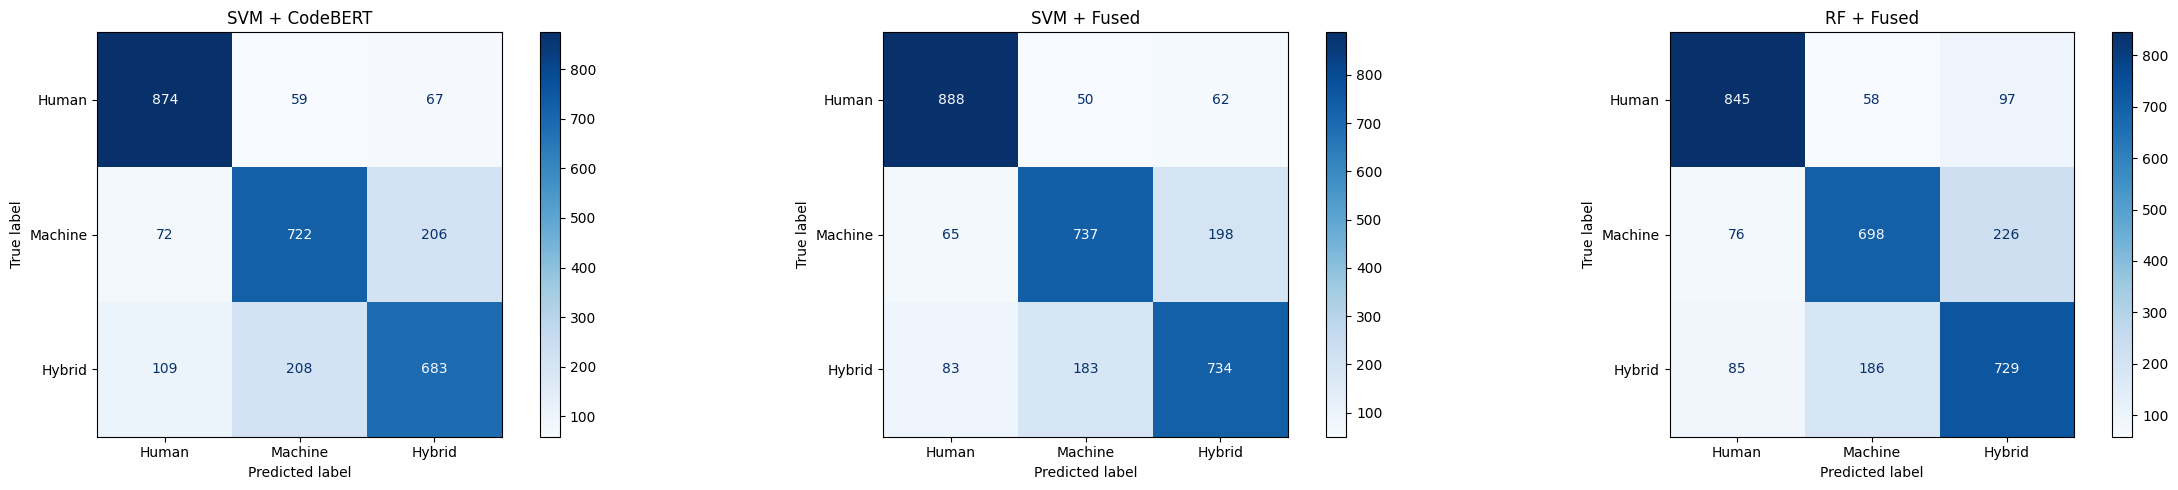


Model                         Acc    Prec     Rec      F1
-------------------------------------------------------
SVM + CodeBERT             0.7597  0.7576  0.7597  0.7583
SVM + Fused                0.7863  0.7851  0.7863  0.7856
RF + Fused                 0.7573  0.7580  0.7573  0.7573

── Detail: SVM + CodeBERT ──
              precision    recall  f1-score   support

       Human       0.83      0.87      0.85      1000
     Machine       0.73      0.72      0.73      1000
      Hybrid       0.71      0.68      0.70      1000

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000


── Detail: SVM + Fused ──
              precision    recall  f1-score   support

       Human       0.86      0.89      0.87      1000
     Machine       0.76      0.74      0.75      1000
      Hybrid       0.74      0.73      0.74      1000

    accuracy                           0.79      3000
 

In [ ]:
#  9. MODEL CODEBERT & FUSED
t0 = time.time()

# Baseline CodeBERT only
svm_cb = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_cb.fit(X_train_cb, y_train_cb)
y_pred_svm_cb = svm_cb.predict(X_test_cb)

# Fused + LinearSVC
svm_fused = LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=2000)
svm_fused.fit(X_train_fused, y_train_cb)
y_pred_fused = svm_fused.predict(X_test_fused)

# Fused + RF
rf_fused = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_fused.fit(X_train_fused, y_train_cb)
y_pred_rf_fused = rf_fused.predict(X_test_fused)

print(f"Models done! ({time.time()-t0:.1f}s)")

#  10. EVALUASI
models_result = {
    'SVM + CodeBERT' : (y_test_cb, y_pred_svm_cb),
    'SVM + Fused'    : (y_test_cb, y_pred_fused),
    'RF + Fused'     : (y_test_cb, y_pred_rf_fused),
}

fig, axes = plt.subplots(1, 3, figsize=(24, 5))
for ax, (name, (y_true, y_pred)) in zip(axes, models_result.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, ax=ax, cmap='Blues',
        display_labels=target_names, values_format='d'
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

print(f"\n{'Model':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7}")
print("-" * 55)
for name, (y_true, y_pred) in models_result.items():
    print(f"{name:<25}"
          f" {accuracy_score(y_true, y_pred):>7.4f}"
          f" {precision_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}"
          f" {recall_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}"
          f" {f1_score(y_true, y_pred, average='weighted', zero_division=0):>7.4f}")

print("\n── Detail: SVM + CodeBERT ──")
print(classification_report(y_test_cb, y_pred_svm_cb,
      target_names=target_names, zero_division=0))

print("\n── Detail: SVM + Fused ──")
print(classification_report(y_test_cb, y_pred_fused,
      target_names=target_names, zero_division=0))

print("\n── Detail: RF + Fused ──")
print(classification_report(y_test_cb, y_pred_rf_fused,
      target_names=target_names, zero_division=0))

**tambahan**

In [ ]:
# 7. CODEBERT
import time
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

print("\nGPU available:", torch.cuda.is_available())
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using:", device)

tokenizer = AutoTokenizer.from_pretrained("microsoft/codebert-base")
codebert  = AutoModel.from_pretrained("microsoft/codebert-base")
codebert.eval()
codebert  = codebert.to(device)

# Langsung pakai df_train & df_test hasil sampling
df_train_cb = df_train.reset_index(drop=True)
df_test_cb  = df_test.reset_index(drop=True)

print(f"Train: {df_train_cb.shape} | Test: {df_test_cb.shape}")

def batch_embed(codes, batch_size=32, max_length=128):
    embeddings = []
    total = len(codes)
    for i in range(0, total, batch_size):
        batch  = [str(c)[:800] for c in codes[i:i+batch_size]]
        inputs = tokenizer(batch, return_tensors='pt', truncation=True,
                           max_length=max_length, padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = codebert(**inputs)
        cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls)
        print(f"  {min(i+batch_size, total)}/{total}", end='\r')
    print()
    return np.vstack(embeddings)

t0 = time.time()
print("Extracting train embeddings...")
X_train_cb = batch_embed(df_train_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print("Extracting test embeddings...")
X_test_cb  = batch_embed(df_test_cb['Code'].tolist(),
                          batch_size=32 if device=='cuda' else 16)
print(f"CodeBERT done! ({time.time()-t0:.1f}s)")

y_train_cb = df_train_cb['label_enc'].values
y_test_cb  = df_test_cb['label_enc'].values


GPU available: False
Using: cpu


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train: (12000, 10) | Test: (3000, 10)
Extracting train embeddings...
  12000/12000
Extracting test embeddings...
  3000/3000
CodeBERT done! (5265.5s)


RF + CodeBERT done! (89.3s)


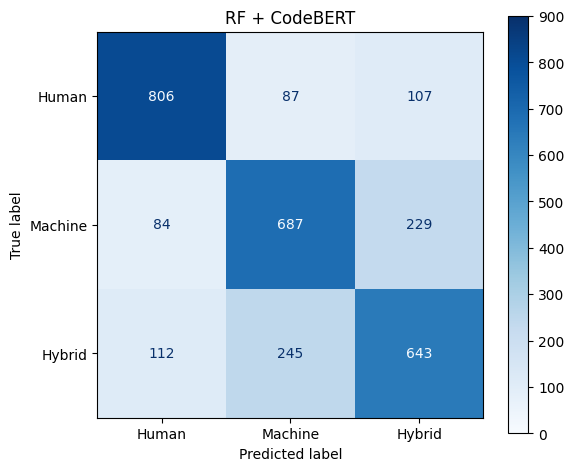

Accuracy  : 0.7120
Precision : 0.7118
Recall    : 0.7120
F1-score  : 0.7119
              precision    recall  f1-score   support

       Human       0.80      0.81      0.81      1000
     Machine       0.67      0.69      0.68      1000
      Hybrid       0.66      0.64      0.65      1000

    accuracy                           0.71      3000
   macro avg       0.71      0.71      0.71      3000
weighted avg       0.71      0.71      0.71      3000



In [ ]:
# RF + CodeBERT
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             ConfusionMatrixDisplay, confusion_matrix)

target_names = le.classes_.tolist()
target_names = ['Human', 'Machine', 'Hybrid']

t0 = time.time()
rf_cb = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_cb.fit(X_train_cb, y_train_cb)
y_pred_rf_cb = rf_cb.predict(X_test_cb)
print(f"RF + CodeBERT done! ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_cb, y_pred_rf_cb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d',
          im_kw={'vmin': 0, 'vmax': 900})
ax.set_title("RF + CodeBERT")
plt.tight_layout()
plt.show()

print("Accuracy  : {:.4f}".format(accuracy_score(y_test_cb, y_pred_rf_cb)))
print("Precision : {:.4f}".format(precision_score(y_test_cb, y_pred_rf_cb, average='weighted', zero_division=0)))
print("Recall    : {:.4f}".format(recall_score(y_test_cb, y_pred_rf_cb, average='weighted', zero_division=0)))
print("F1-score  : {:.4f}".format(f1_score(y_test_cb, y_pred_rf_cb, average='weighted', zero_division=0)))
print(classification_report(y_test_cb, y_pred_rf_cb, target_names=target_names, zero_division=0))

In [ ]:
# Input user
def predict_code(code_snippet):
    label_names = {
        0: 'HUMAN_GENERATED',
        1: 'MACHINE_GENERATED',
        2: 'MACHINE_REFINED (Hybrid)'
    }

    stylo          = pd.DataFrame([extract_stylometric(code_snippet)])
    pred_rf        = rf.predict(stylo.values)[0]

    emb            = batch_embed([code_snippet], batch_size=1, max_length=128)
    tfidf_vec      = tfidf.transform([code_snippet]).toarray()
    stylo_scaled   = scaler_cb.transform(stylo.values)
    fused          = np.hstack([emb, stylo_scaled, tfidf_vec])
    pred_svm_fused = svm_fused.predict(fused)[0]

    print("\n")
    print("  HASIL KLASIFIKASI CODE")
    print(f"  {'Model':<25} {'Prediksi'}")
    print(f"  {'-' * 45}")
    print(f"  {'RF  (Stylometric)':<25} {label_names[pred_rf]}")
    print(f"  {'SVM (Fused)':<25} {label_names[pred_svm_fused]}")

    return {
        "RF_Stylometric": label_names[pred_rf],
        "SVM_Fused"     : label_names[pred_svm_fused],
    }

print("Paste code Python,")
print("Ketik END di baris baru untuk selesai.\n")

lines = []

while True:
    try:
        line = input()
    except EOFError:
        break

    if line.strip().upper() == "END":
        break
    lines.append(line)

user_code = "\n".join(lines)

if user_code.strip():
    result = predict_code(user_code)
else:
    print("Tidak ada code yang diinput.")

Paste code Python,
Ketik END di baris baru untuk selesai.

for i in range(n): print(i)
END
  1/1


  HASIL KLASIFIKASI CODE
  Model                     Prediksi
  ---------------------------------------------
  RF  (Stylometric)         MACHINE_GENERATED
  SVM (Fused)               MACHINE_GENERATED
